In [8]:
import wandb
import pandas as pd
import ICIW_Plots
import matplotlib.pyplot as plt
from wandb_util import extract_run_data

plt.style.use("ICIWstyle")
plt.rcParams["font.size"] = 7

In [9]:
run_id = "j11icqt4"
run_url = f"ice_ulm/HSA_MGA_nRTD/{run_id}"

In [10]:
api = wandb.Api()
run = api.run(run_url)

In [11]:
run_name, run_data = extract_run_data(run_url)
print(run_data)

           name    epoch  test/loss  train/loss  trainer/global_step  n_in  \
0  rose-sweep-4  1000000   0.000006    0.000005              1000000    91   

        t_in  n_out    t_out  n_kernel   t_kernel  delta_t_out kernel_sizes  \
0  [0, 22.5]    181  [0, 45]        91  [0, 22.5]         0.25         [91]   

  kernel_times  t_kernel_max  learning_rate  use_scheduler  \
0  [[0, 22.5]]          22.5          0.004           True   

                   scheduler_kwargs  lrscheduler_factor  lrscheduler_patience  
0  {'factor': 0.65, 'patience': 94}                0.65                    94  


In [12]:
orig_data = pd.DataFrame(run.scan_history(keys=["train/loss", "epoch"]))

In [13]:
data = orig_data.copy()
data = data.loc[:400]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


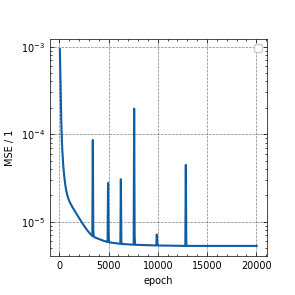

In [14]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel="epoch",
    ylabel="MSE / 1",
    yscale="log",
)
ax.plot(data["epoch"], data["train/loss"])
# ax.plot(data.loc[-1, "epoch"], run_data["test/loss"], "o")
ax.legend()
plt.savefig("75ml_loss.png", dpi=600)